In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
csv_path = Path(r"C:/Users/maria/Desktop/UNI/TGF/TFG/escenarios/non_iid/results_non_iid/metricas_por_hospital_y_ronda_fedavg.csv")
df = pd.read_csv(csv_path)

df.head()

,ronda,hospital,train_loss,train_acc,test_loss,test_acc,train_samples,val_samples,test_samples
0,1,Hospital_1,0.108230,0.970250,0.109115,0.995972,7395,1476,993
1,1,Hospital_2,0.117968,0.968178,0.150447,0.998077,7762,1550,1040
2,1,Hospital_3,0.071076,0.979404,0.243068,0.968784,13886,2774,1858
3,1,Hospital_4,0.107893,0.976477,0.189041,0.998991,7397,1478,991
4,1,Hospital_5,0.111610,0.968444,0.070830,0.996146,7764,1552,1038


In [ ]:
# Ver el contenido del DataFrame
print(df.shape)
df

(25, 9)


,ronda,hospital,train_loss,train_acc,test_loss,test_acc,train_samples,val_samples,test_samples
0,1,Hospital_1,0.108230,0.970250,0.109115,0.995972,7395,1476,993
1,1,Hospital_2,0.117968,0.968178,0.150447,0.998077,7762,1550,1040
2,1,Hospital_3,0.071076,0.979404,0.243068,0.968784,13886,2774,1858
3,1,Hospital_4,0.107893,0.976477,0.189041,0.998991,7397,1478,991
4,1,Hospital_5,0.111610,0.968444,0.070830,0.996146,7764,1552,1038
5,2,Hospital_1,0.021544,0.993374,0.010044,0.997986,7395,1476,993
6,2,Hospital_2,0.016559,0.996006,0.030724,0.998077,7762,1550,1040
7,2,Hospital_3,0.015832,0.994959,0.113352,0.974166,13886,2774,1858
8,2,Hospital_4,0.020298,0.995268,0.003613,0.998991,7397,1478,991
9,2,Hospital_5,0.024933,0.994719,0.032911,0.995183,7764,1552,1038


In [ ]:
# Media por ronda
df_round = df.groupby("ronda", as_index=False).agg({
    "test_loss": "mean",
    "test_acc": "mean",
    "train_loss": "mean",
    "train_acc": "mean"
})

df_round

,ronda,test_loss,test_acc,train_loss,train_acc
0,1,0.152500,0.991594,0.103355,0.972551
1,2,0.038129,0.992881,0.019833,0.994865
2,3,0.009520,0.998229,0.009823,0.997319
3,4,0.009060,0.997575,0.007006,0.997981
4,5,0.005307,0.998674,0.006296,0.998597


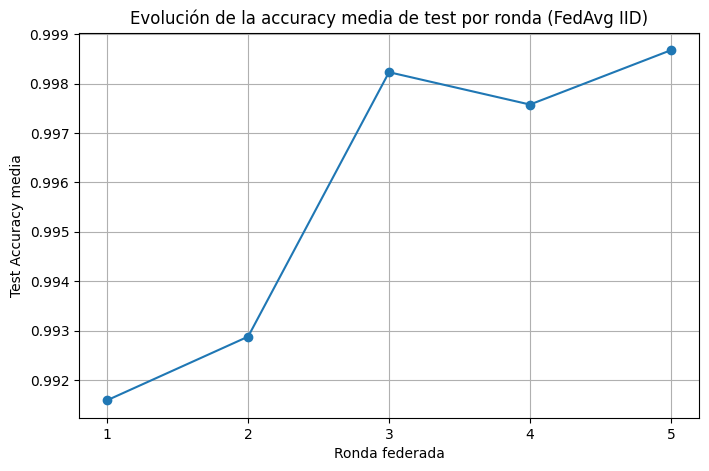

In [ ]:
# gráfica de accuracy media por ronda
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_acc"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Accuracy media")
plt.title("Evolución de la accuracy media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.show()

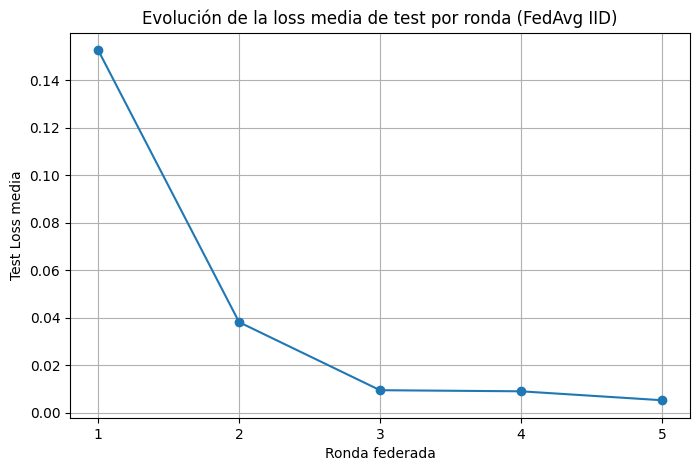

In [ ]:
# gráfica de loss media por ronda
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_loss"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Loss media")
plt.title("Evolución de la loss media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.show()

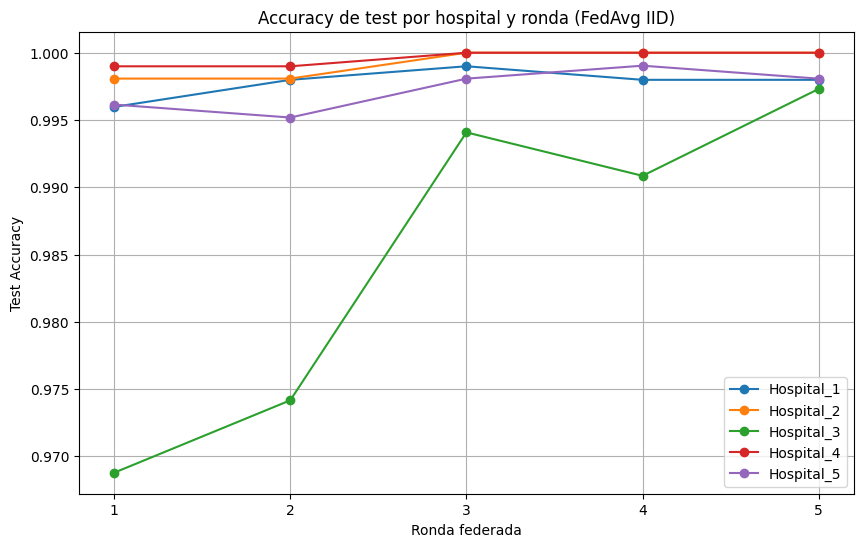

In [ ]:
# accuracy de test por hospital
plt.figure(figsize=(10,6))

for hospital in df["hospital"].unique():
    df_h = df[df["hospital"] == hospital]
    plt.plot(df_h["ronda"], df_h["test_acc"], marker="o", label=hospital)

plt.xlabel("Ronda federada")
plt.ylabel("Test Accuracy")
plt.title("Accuracy de test por hospital y ronda (FedAvg IID)")
plt.xticks(sorted(df["ronda"].unique()))
plt.grid(True)
plt.legend()
plt.show()

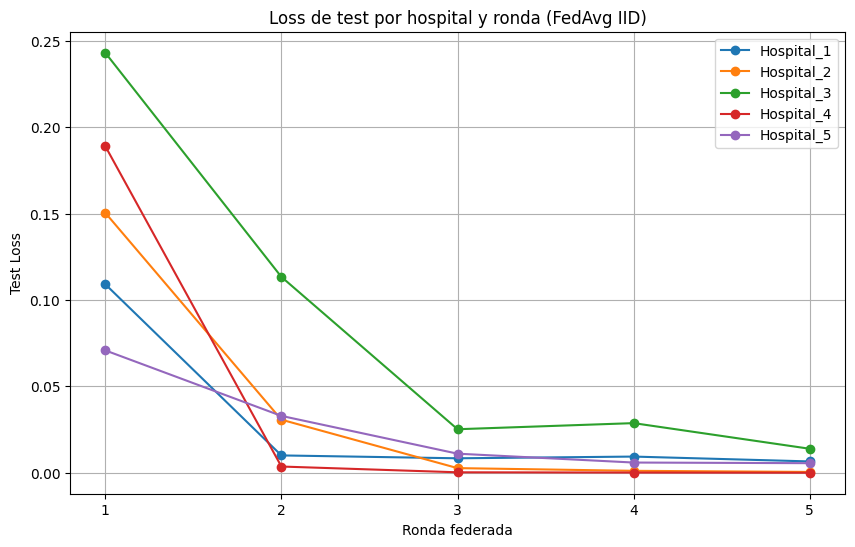

In [ ]:
# loss de test por hospital
plt.figure(figsize=(10,6))

for hospital in df["hospital"].unique():
    df_h = df[df["hospital"] == hospital]
    plt.plot(df_h["ronda"], df_h["test_loss"], marker="o", label=hospital)

plt.xlabel("Ronda federada")
plt.ylabel("Test Loss")
plt.title("Loss de test por hospital y ronda (FedAvg IID)")
plt.xticks(sorted(df["ronda"].unique()))
plt.grid(True)
plt.legend()
plt.show()

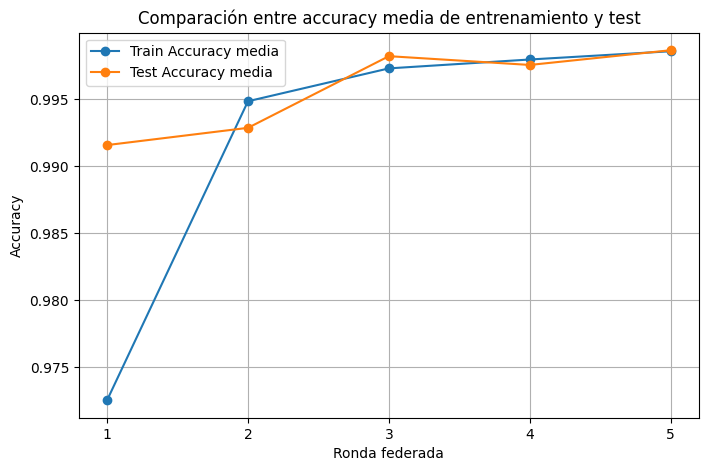

In [ ]:
# accuracy de train vs test media
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["train_acc"], marker="o", label="Train Accuracy media")
plt.plot(df_round["ronda"], df_round["test_acc"], marker="o", label="Test Accuracy media")

plt.xlabel("Ronda federada")
plt.ylabel("Accuracy")
plt.title("Comparación entre accuracy media de entrenamiento y test")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.legend()
plt.show()

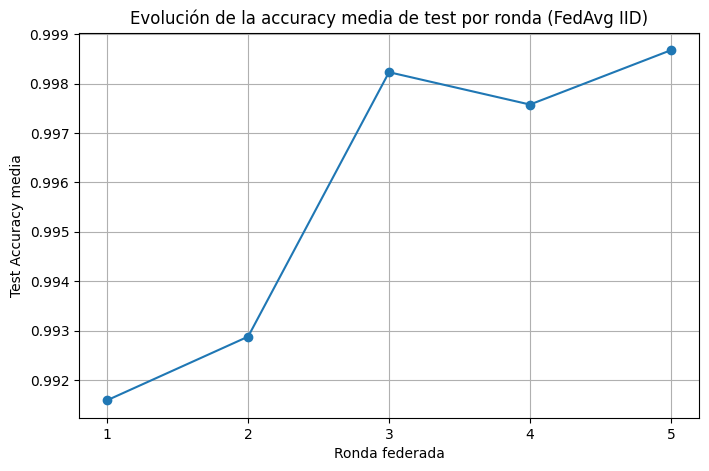

In [ ]:
# guardar las gráficas
output_dir = csv_path.parent / "graficas"
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_acc"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Accuracy media")
plt.title("Evolución de la accuracy media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.savefig(output_dir / "accuracy_media_por_ronda.png", bbox_inches="tight")
plt.show()

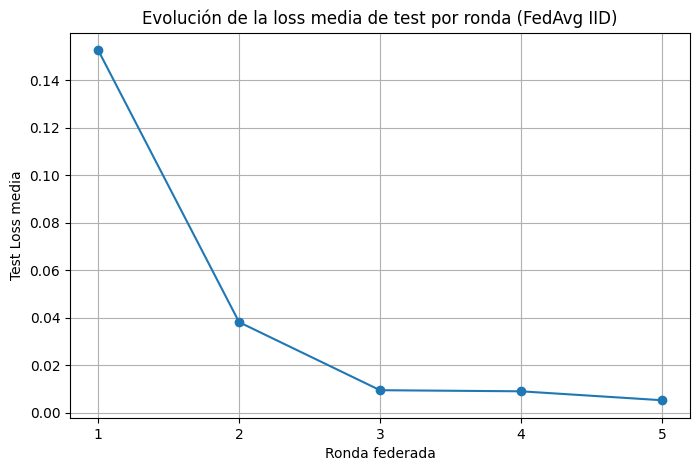

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_loss"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Loss media")
plt.title("Evolución de la loss media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.savefig(output_dir / "loss_media_por_ronda.png", bbox_inches="tight")
plt.show()

In [ ]:
# resumen
df_round = df.groupby("ronda", as_index=False).agg({
    "train_loss": "mean",
    "train_acc": "mean",
    "test_loss": "mean",
    "test_acc": "mean"
})

df_round = df_round.rename(columns={
    "ronda": "Ronda",
    "train_loss": "Train Loss Medio",
    "train_acc": "Train Acc Media",
    "test_loss": "Test Loss Medio",
    "test_acc": "Test Acc Media"
})

df_round = df_round.round(4)

df_round.to_csv(output_dir / "resumen_metricas_por_ronda.csv", index=False)